In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
from google.colab import files

uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [3]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  704

In [5]:
print("Missing values:")
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Total missing values: 0


In [6]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print("Missing values after converting TotalCharges:")
print(df["TotalCharges"].isnull().sum())

Missing values after converting TotalCharges:
11


In [7]:
df["Average_Monthly_Spend"] = np.where(
    df["tenure"] > 0,
    df["TotalCharges"] / df["tenure"],
    df["MonthlyCharges"]
)

print("New feature created: Average_Monthly_Spend")

df[
    [
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "Average_Monthly_Spend"
    ]
].head()

New feature created: Average_Monthly_Spend


,tenure,MonthlyCharges,TotalCharges,Average_Monthly_Spend
0,1,29.85,29.85,29.850000
1,34,56.95,1889.50,55.573529
2,2,53.85,108.15,54.075000
3,45,42.30,1840.75,40.905556
4,2,70.70,151.65,75.825000


In [8]:
print("Missing values before imputation:")
print(df.isnull().sum())

Missing values before imputation:
customerID                0
gender                    0
SeniorCitizen             0
Partner                   0
Dependents                0
tenure                    0
PhoneService              0
MultipleLines             0
InternetService           0
OnlineSecurity            0
OnlineBackup              0
DeviceProtection          0
TechSupport               0
StreamingTV               0
StreamingMovies           0
Contract                  0
PaperlessBilling          0
PaymentMethod             0
MonthlyCharges            0
TotalCharges             11
Churn                     0
Average_Monthly_Spend     0
dtype: int64


In [9]:
df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

print(df["Churn"].value_counts())

print("\n0 = No Churn")
print("1 = Churn")

Churn
0    5174
1    1869
Name: count, dtype: int64

0 = No Churn
1 = Churn


In [10]:
X = df.drop(
    columns=["Churn", "customerID"]
)

y = df["Churn"]

print("Features:")
print(X.columns.tolist())

print("\nTarget: Churn")

Features:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Average_Monthly_Spend']

Target: Churn


In [11]:
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Average_Monthly_Spend']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [12]:
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 5634
Testing samples: 1409


In [14]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [15]:
y_pred = model.predict(X_test)

y_probability = model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully!")

Predictions generated successfully!


In [16]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("MODEL EVALUATION")
print("================")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

MODEL EVALUATION
Accuracy : 0.8062455642299503
Precision: 0.658307210031348
Recall   : 0.5614973262032086
F1 Score : 0.6060606060606061


In [17]:
roc_auc = roc_auc_score(
    y_test,
    y_probability
)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.8418998165801235


In [18]:
print("Classification Report")
print("=====================")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No Churn", "Churn"]
    )
)

Classification Report
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [19]:
print("Classification Report")
print("=====================")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No Churn", "Churn"]
    )
)

Classification Report
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



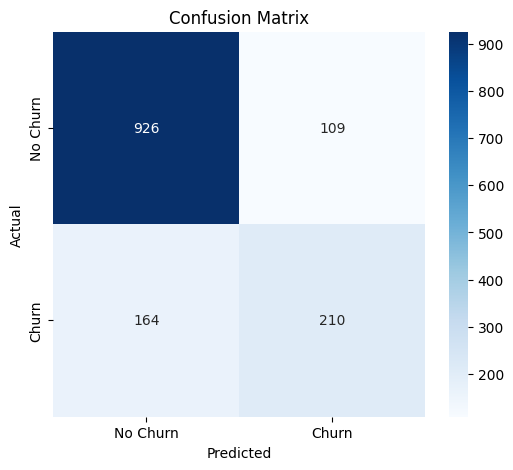

In [20]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

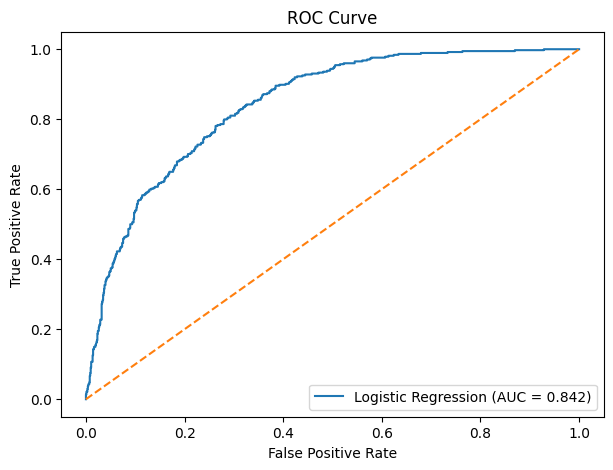

In [21]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [22]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("5-Fold Cross-Validation Accuracy:")
print(cv_scores)

print("\nMean CV Accuracy:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

5-Fold Cross-Validation Accuracy:
[0.80766501 0.81192335 0.81973031 0.7890625  0.79474432]

Mean CV Accuracy: 0.8046250967804374
Standard Deviation: 0.011229399804987513


In [23]:
cv_auc_scores = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring="roc_auc"
)

print("5-Fold Cross-Validation ROC-AUC:")
print(cv_auc_scores)

print("\nMean CV ROC-AUC:", cv_auc_scores.mean())

5-Fold Cross-Validation ROC-AUC:
[0.85364256 0.84542613 0.86347878 0.82533447 0.83641872]

Mean CV ROC-AUC: 0.8448601316382434


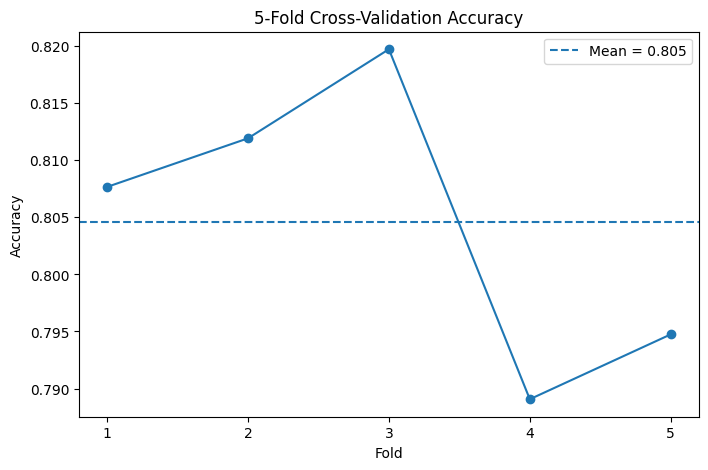

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 6),
    cv_scores,
    marker="o"
)

plt.axhline(
    cv_scores.mean(),
    linestyle="--",
    label=f"Mean = {cv_scores.mean():.3f}"
)

plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("5-Fold Cross-Validation Accuracy")
plt.xticks(range(1, 6))
plt.legend()
plt.show()

In [26]:
print("FINAL PROJECT SUMMARY")
print("=====================")

print(f"Test Accuracy  : {accuracy:.3f}")
print(f"Precision      : {precision:.3f}")
print(f"Recall         : {recall:.3f}")
print(f"F1 Score       : {f1:.3f}")
print(f"ROC-AUC        : {roc_auc:.3f}")
print(f"Mean CV Accuracy: {cv_scores.mean():.3f}")
print(f"Mean CV ROC-AUC : {cv_auc_scores.mean():.3f}")

print("\nTechniques implemented:")
print(" Train/Test Split")
print(" 5-Fold Cross-Validation")
print(" Missing Data Handling")
print(" Feature Engineering")
print(" Feature Scaling")
print(" Confusion Matrix")
print(" Precision")
print(" Recall")
print(" F1 Score")
print(" ROC-AUC")
print(" ROC Curve")

FINAL PROJECT SUMMARY
Test Accuracy  : 0.806
Precision      : 0.658
Recall         : 0.561
F1 Score       : 0.606
ROC-AUC        : 0.842
Mean CV Accuracy: 0.805
Mean CV ROC-AUC : 0.845

Techniques implemented:
 Train/Test Split
 5-Fold Cross-Validation
 Missing Data Handling
 Feature Engineering
 Feature Scaling
 Confusion Matrix
 Precision
 Recall
 F1 Score
 ROC-AUC
 ROC Curve
